# Ablation Experiment Analysis
## 2 Inputs × 3 Outputs | 3 Replicates per Condition

Data is loaded from **`../data/ablation_data.xlsx`** (initial DOE + BO campaign
samples — currently 15 conditions × 3 replicates, including the BO campaign
samples at X1 = 19.6, X2 = 2.0 (July 2026) and X1 = 17.4, X2 = 1.0 (August 2026)). Append new replicate rows to the spreadsheet and re-run
all cells to refresh the analysis.

**Inputs:**
- $X_1$: Carbon black wt%
- $X_2$: Fe-rich regolith wt%

**Outputs:**
- $Y_1$: Linear ablative rate (µm/s)
- $Y_2$: Backside temperature (°C)
- $Y_3$: Density (g/cm³)

---
**Workflow:**
1. Data loading & exploration
2. ANOVA with orthogonality check
3. Linear regression models (one per output)
4. Heteroscedastic Multi-Output Gaussian Process (MOGP)

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from itertools import product as iproduct

# ── Statistics ───────────────────────────────────────────────────────────────
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ── PyTorch / GPyTorch ────────────────────────────────────────────────────────
import torch
import gpytorch
from gpytorch.models import ExactGP
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.distributions import MultitaskMultivariateNormal
from gpytorch.kernels import MultitaskKernel, RBFKernel, ScaleKernel
from gpytorch.means import ConstantMean, MultitaskMean

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print(f"PyTorch {torch.__version__} | GPyTorch {gpytorch.__version__}")

PyTorch 2.7.1+cu118 | GPyTorch 1.14


## 1. Data Loading & Exploration

In [2]:
# ── Load replicate data from Excel ───────────────────────────────────────────
DATA_FILE = '../data/ablation_data.xlsx'

def find_col(columns, keyword):
    """Return the unique column whose name contains `keyword` (case-insensitive)."""
    hits = [c for c in columns if keyword.lower() in str(c).lower()]
    assert len(hits) == 1, f"Expected exactly one column matching '{keyword}', found: {hits}"
    return hits[0]

df_xlsx = pd.read_excel(DATA_FILE)
col_map = {
    find_col(df_xlsx.columns, 'carbon black'): 'X1',
    find_col(df_xlsx.columns, 'regolith'):     'X2',
    find_col(df_xlsx.columns, 'ablative'):     'Y1',
    find_col(df_xlsx.columns, 'backside'):     'Y2',
    find_col(df_xlsx.columns, 'density'):      'Y3',
}
df = df_xlsx.rename(columns=col_map)[['X1', 'X2', 'Y1', 'Y2', 'Y3']].astype(float)

# Create condition label
df['Condition'] = df.apply(lambda r: f"X1={r.X1:.1f}, X2={r.X2:.0f}", axis=1)

print(f"Dataset shape: {df.shape}")
print(f"Unique conditions: {df[['X1','X2']].drop_duplicates().shape[0]}")
print(f"Replicates per condition: {df.groupby(['X1','X2']).size().unique().tolist()}")
print()
df[['X1','X2','Y1','Y2','Y3']].describe().round(4)


Dataset shape: (45, 6)
Unique conditions: 15
Replicates per condition: [3]



,X1,X2,Y1,Y2,Y3
count,45.0000,45.0000,45.0000,45.0000,45.0000
mean,12.3000,2.8000,8.7753,197.2000,1.1877
std,6.0471,1.4397,3.8421,17.6617,0.0318
min,5.0000,1.0000,5.5300,161.0000,1.1350
25%,5.0000,1.0000,6.1000,184.0000,1.1630
50%,12.5000,3.0000,6.8200,201.0000,1.1900
75%,19.6000,4.0000,10.7800,213.0000,1.2110
max,20.0000,5.0000,19.2100,227.0000,1.2510


In [3]:
# Design matrix – unique conditions
design = df[['X1','X2']].drop_duplicates().sort_values(['X1','X2']).reset_index(drop=True)
print("Experimental Design (unique X1, X2 combinations):")
print(design.to_string(index=False))

Experimental Design (unique X1, X2 combinations):
  X1  X2
 5.0 1.0
 5.0 2.0
 5.0 3.0
 5.0 4.0
 5.0 5.0
10.0 3.0
12.5 1.0
12.5 3.0
12.5 5.0
15.0 3.0
17.4 1.0
19.6 2.0
20.0 1.0
20.0 3.0
20.0 5.0


In [4]:
# ── BO campaign samples (for plot annotations) ───────────────────────────────
# Tested iterations (triangles) and the next proposal (gold star). Keep in sync with
# mobo_analysis_v4.ipynb (Section 1.1 ITERATION_SAMPLES / Section 6 proposal).
CAMPAIGN_SAMPLES = {1: (19.6, 2.0),    # Jul 2026
                    2: (17.4, 1.0)}    # Aug 2026
PROPOSED_NEXT    = (20.0, 2.16)        # iteration-3 proposal (mobo_analysis_v4, Sep 2026)
CAMPAIGN_COLORS  = {1: 'limegreen', 2: 'darkorange', 3: 'seagreen'}

def is_campaign(x1, x2):
    return np.any([np.isclose(x1, a) & np.isclose(x2, b) for a, b in CAMPAIGN_SAMPLES.values()], axis=0)

def mark_campaign(ax, legend=False, doe_color='white'):
    """Initial DOE (dots), tested campaign samples (triangles), next proposal (star)."""
    init = ~is_campaign(df.X1.values, df.X2.values)
    ax.scatter(df.X1[init], df.X2[init], c=doe_color, edgecolors='k', s=40, zorder=5,
               label='Initial DOE' if legend else None)
    for it, (x1, x2) in CAMPAIGN_SAMPLES.items():
        ax.scatter(x1, x2, c=CAMPAIGN_COLORS.get(it, 'gray'), marker='^', s=170, edgecolors='k',
                   zorder=6, label=f'Iteration {it}' if legend else None)
    ax.scatter(*PROPOSED_NEXT, c='gold', marker='*', s=240, edgecolors='k', zorder=6,
               label=f'Proposed (iter {max(CAMPAIGN_SAMPLES) + 1})' if legend else None)
    if legend:
        ax.legend(fontsize=7, loc='upper left', framealpha=0.9)

print("Campaign samples:", CAMPAIGN_SAMPLES, "| next proposal:", PROPOSED_NEXT)


Campaign samples: {1: (19.6, 2.0), 2: (17.4, 1.0)} | next proposal: (20.0, 2.16)


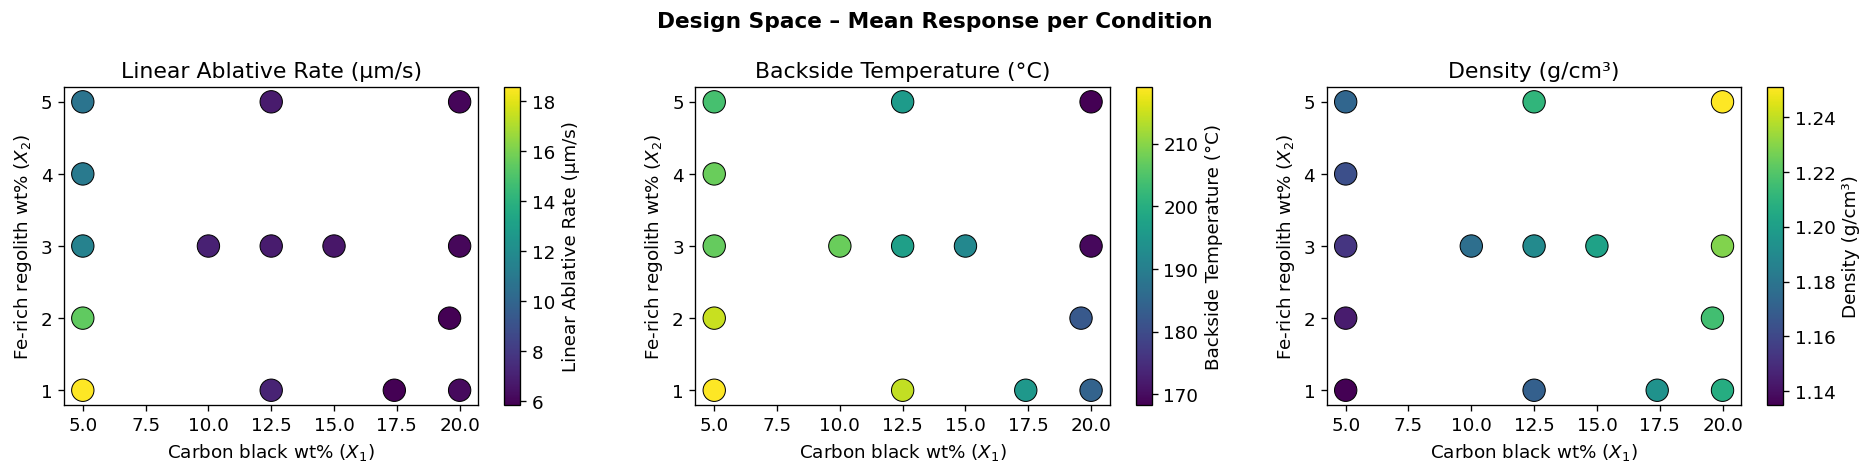

In [5]:
# Visualise design space
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

outputs = [('Y1', 'Linear Ablative Rate (µm/s)'),
           ('Y2', 'Backside Temperature (°C)'),
           ('Y3', 'Density (g/cm³)')]

for ax, (col, label) in zip(axes, outputs):
    means = df.groupby(['X1', 'X2'])[col].mean().reset_index()
    sc = ax.scatter(means['X1'], means['X2'], c=means[col],
                    s=180, cmap='viridis', edgecolors='k', linewidths=0.6)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel('Carbon black wt% ($X_1$)')
    ax.set_ylabel('Fe-rich regolith wt% ($X_2$)')
    ax.set_title(label)

plt.suptitle('Design Space – Mean Response per Condition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. ANOVA & Orthogonality Analysis

### 2.1 Orthogonality Check

A design is **orthogonal** if the columns of the model matrix $\mathbf{X}$ are mutually uncorrelated, i.e.:
$$\mathbf{X}^\top \mathbf{X} = n\,\mathbf{I}$$
We check this by (a) the Pearson correlation between $X_1$ and $X_2$ and (b) the condition number of $\mathbf{X}^\top\mathbf{X}$.

In [6]:
from numpy.linalg import cond, eigvalsh

x1 = df['X1'].values
x2 = df['X2'].values

# Pearson correlation
r_pearson, p_pearson = stats.pearsonr(x1, x2)
print("=" * 55)
print("  ORTHOGONALITY CHECK")
print("=" * 55)
print(f"  Pearson r(X1, X2)  = {r_pearson:+.4f}  (p = {p_pearson:.4f})")

# Build model matrix (intercept + X1 + X2 + X1*X2)
X_mat = np.column_stack([np.ones(len(x1)), x1, x2, x1*x2])
XtX   = X_mat.T @ X_mat
cond_num = cond(XtX)
print(f"  Condition number κ(X'X) = {cond_num:.2f}")

# Centred version (standard check)
x1c = x1 - x1.mean()
x2c = x2 - x2.mean()
X_cent = np.column_stack([np.ones(len(x1c)), x1c, x2c, x1c*x2c])
XtX_c  = X_cent.T @ X_cent
cond_c = cond(XtX_c)
D = np.diag(1/np.sqrt(np.diag(XtX_c)))
corr_mat = D @ XtX_c @ D        # normalised X'X → correlation matrix
print(f"  Condition number κ(X'X, centred) = {cond_c:.2f}")
print()
print("  Normalised X'X (centred design):")
labels = ['1', 'X1c', 'X2c', 'X1c·X2c']
cm_df = pd.DataFrame(corr_mat, index=labels, columns=labels)
print(cm_df.round(4).to_string())

print()
if abs(r_pearson) < 0.10:
    print("  ✅  X1 and X2 are weakly correlated — near-orthogonal main effects.")
elif abs(r_pearson) < 0.40:
    print("  ⚠️  Mild correlation between X1 and X2; partial non-orthogonality.")
else:
    print("  ❌  Strong correlation between X1 and X2; design is non-orthogonal.")

if cond_c < 30:
    print("  ✅  Condition number < 30: well-conditioned (good orthogonality).")
elif cond_c < 100:
    print("  ⚠️  Condition number moderate: mild multicollinearity present.")
else:
    print("  ❌  Large condition number: severe multicollinearity / non-orthogonality.")

  ORTHOGONALITY CHECK
  Pearson r(X1, X2)  = -0.1371  (p = 0.3693)
  Condition number κ(X'X) = 57508.37
  Condition number κ(X'X, centred) = 77.72

  Normalised X'X (centred design):
              1     X1c     X2c  X1c·X2c
1        1.0000  0.0000  0.0000  -0.1336
X1c      0.0000  1.0000 -0.1371   0.0025
X2c      0.0000 -0.1371  1.0000   0.0584
X1c·X2c -0.1336  0.0025  0.0584   1.0000

  ⚠️  Mild correlation between X1 and X2; partial non-orthogonality.
  ⚠️  Condition number moderate: mild multicollinearity present.


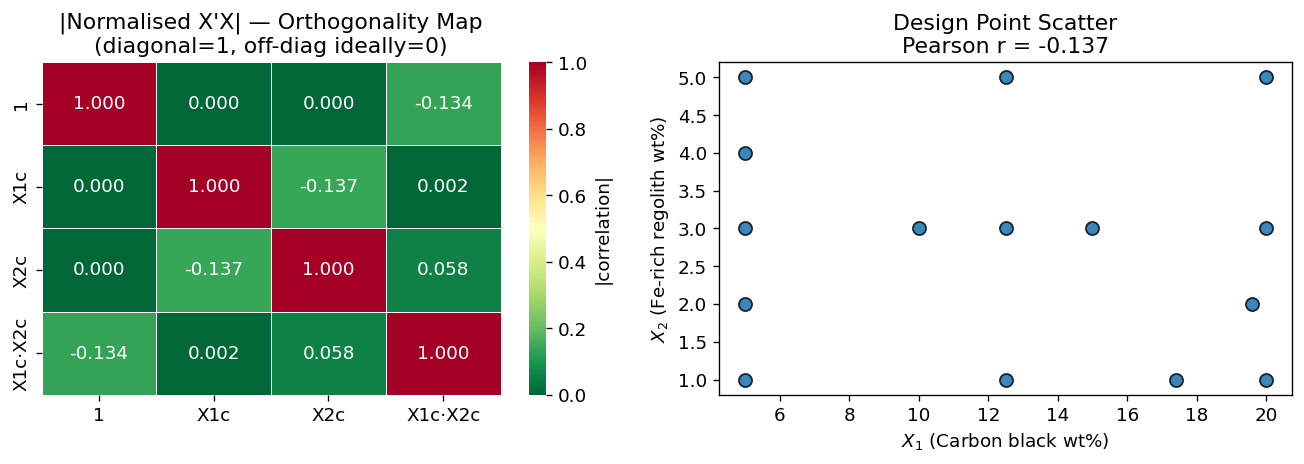

In [7]:
# Visualise the normalised X'X heatmap
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm_df.abs(), annot=cm_df.round(3), fmt='.3f',
            cmap='RdYlGn_r', vmin=0, vmax=1, ax=axes[0],
            linewidths=0.5, cbar_kws={'label': '|correlation|'})
axes[0].set_title('|Normalised X\'X| — Orthogonality Map\n(diagonal=1, off-diag ideally=0)')

# Scatter of X1 vs X2
axes[1].scatter(x1, x2, alpha=0.5, edgecolors='k', s=60)
axes[1].set_xlabel('$X_1$ (Carbon black wt%)')
axes[1].set_ylabel('$X_2$ (Fe-rich regolith wt%)')
axes[1].set_title(f'Design Point Scatter\nPearson r = {r_pearson:+.3f}')

plt.tight_layout()
plt.show()

### 2.2 Two-Way ANOVA (for each output)

Model: $Y = \mu + \alpha_{X_1} + \beta_{X_2} + (\alpha\beta)_{X_1 X_2} + \varepsilon$

We treat $X_1$ and $X_2$ as **categorical factors** (since they take discrete, designed levels) and fit a standard two-way ANOVA with interaction.

**Note (incomplete factorial):** with the BO campaign samples added, only part of the
full X1×X2 grid is observed (15 of 35 cells), and new X1 levels can appear at a single
X2. Type-II tests from the full interaction model are then non-estimable (statsmodels
returns F≈0/negative with p=1). We therefore test **main effects from the additive
model** and the **interaction via an F-test comparing the additive vs. full model**.


In [8]:
df['X1_cat'] = df['X1'].astype(str)
df['X2_cat'] = df['X2'].astype(str)

# Main effects from the additive model (estimable on the incomplete factorial);
# interaction from an F-test of additive vs. full interaction model.
anova_results = {}
for col, label in outputs:
    m_add  = ols(f"{col} ~ C(X1_cat) + C(X2_cat)", data=df).fit()
    m_full = ols(f"{col} ~ C(X1_cat) + C(X2_cat) + C(X1_cat):C(X2_cat)", data=df).fit()

    table = anova_lm(m_add, typ=2)                    # main-effect SS (estimable)
    comp  = anova_lm(m_add, m_full)                   # interaction test
    # Test main effects against the full model's pure-error MSE (the additive
    # model's residual still contains the interaction variance)
    mse_full = m_full.ssr / m_full.df_resid
    for term in ['C(X1_cat)', 'C(X2_cat)']:
        F = (table.loc[term, 'sum_sq'] / table.loc[term, 'df']) / mse_full
        table.loc[term, 'F'] = F
        table.loc[term, 'PR(>F)'] = stats.f.sf(F, table.loc[term, 'df'], m_full.df_resid)
    table.loc['C(X1_cat):C(X2_cat)'] = {
        'sum_sq': comp.loc[1, 'ss_diff'], 'df': comp.loc[1, 'df_diff'],
        'F': comp.loc[1, 'F'], 'PR(>F)': comp.loc[1, 'Pr(>F)'],
    }
    table.loc['Residual'] = {'sum_sq': m_full.ssr, 'df': m_full.df_resid,
                             'F': np.nan, 'PR(>F)': np.nan}
    table = table.loc[['C(X1_cat)', 'C(X2_cat)', 'C(X1_cat):C(X2_cat)', 'Residual']]
    anova_results[col] = (m_full, table)

for col, label in outputs:
    model, table = anova_results[col]
    print(f"\n{'─'*60}")
    print(f"  ANOVA for {label}")
    print(f"{'─'*60}")
    print(table.round(4).to_string())
    print(f"  R² (full model) = {model.rsquared:.4f}  |  Adj R² = {model.rsquared_adj:.4f}")



────────────────────────────────────────────────────────────
  ANOVA for Linear Ablative Rate (µm/s)
────────────────────────────────────────────────────────────
                       sum_sq    df         F  PR(>F)
C(X1_cat)            496.8514   6.0  213.2092     0.0
C(X2_cat)             70.9430   4.0   45.6647     0.0
C(X1_cat):C(X2_cat)   70.8827   4.0   45.6259     0.0
Residual              11.6517  30.0       NaN     NaN
  R² (full model) = 0.9821  |  Adj R² = 0.9737

────────────────────────────────────────────────────────────
  ANOVA for Backside Temperature (°C)
────────────────────────────────────────────────────────────
                        sum_sq    df        F  PR(>F)
C(X1_cat)            8914.5944   6.0  13.2081  0.0000
C(X2_cat)            1567.8222   4.0   3.4844  0.0188
C(X1_cat):C(X2_cat)    25.1111   4.0   0.0558  0.9939
Residual             3374.6667  30.0      NaN     NaN
  R² (full model) = 0.7541  |  Adj R² = 0.6394

─────────────────────────────────────────

In [9]:
# Summary: p-values and significance flags
rows = []
for col, label in outputs:
    _, table = anova_results[col]
    for term in table.index:
        rows.append({'Output': col, 'Term': term,
                     'SS': table.loc[term,'sum_sq'],
                     'F':  table.loc[term,'F'],
                     'p':  table.loc[term,'PR(>F)']})

anova_summary = pd.DataFrame(rows).dropna(subset=['p'])
anova_summary['Significant'] = anova_summary['p'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))

print("ANOVA Summary (p-values):")
print(anova_summary[['Output','Term','F','p','Significant']].to_string(index=False))

ANOVA Summary (p-values):
Output                Term            F            p Significant
    Y1           C(X1_cat) 2.132092e+02 3.281948e-23         ***
    Y1           C(X2_cat) 4.566469e+01 2.421489e-12         ***
    Y1 C(X1_cat):C(X2_cat) 4.562587e+01 2.447894e-12         ***
    Y2           C(X1_cat) 1.320811e+01 2.856164e-07         ***
    Y2           C(X2_cat) 3.484394e+00 1.881760e-02           *
    Y2 C(X1_cat):C(X2_cat) 5.580798e-02 9.938889e-01            
    Y3           C(X1_cat) 7.497604e+28 0.000000e+00         ***
    Y3           C(X2_cat) 2.569401e+28 0.000000e+00         ***
    Y3 C(X1_cat):C(X2_cat) 8.873554e+25 0.000000e+00         ***


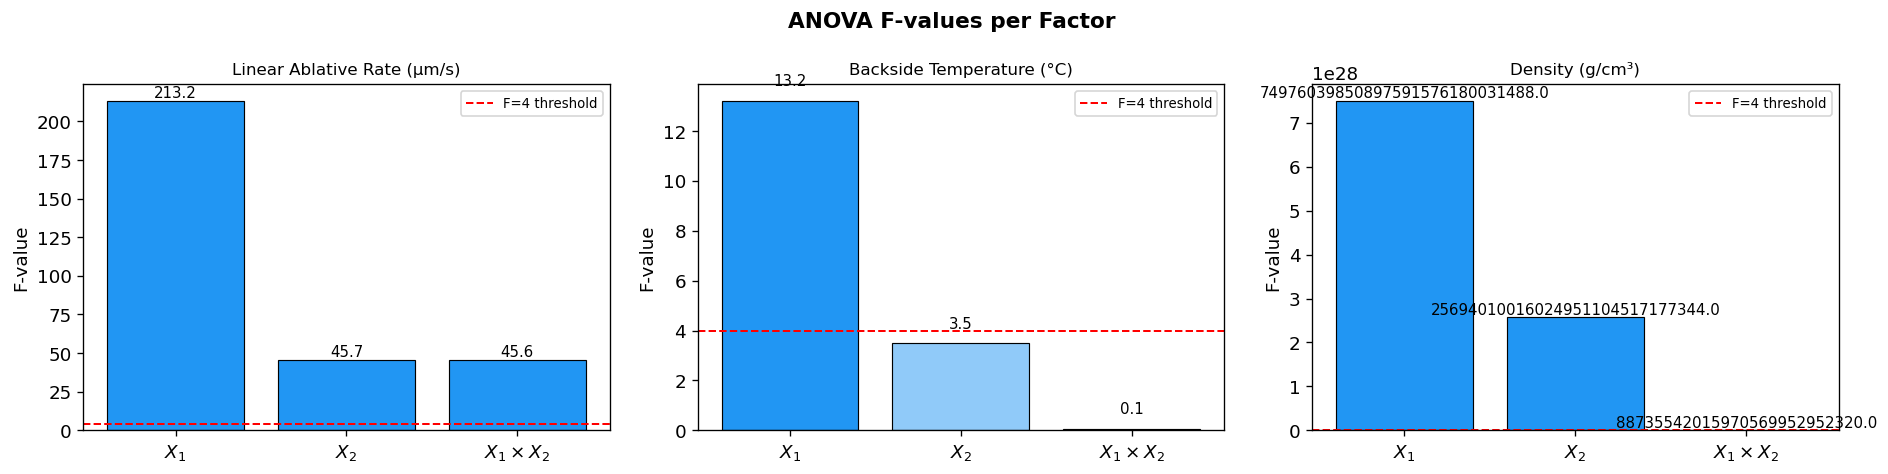

In [10]:
# ANOVA F-value bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

term_labels = {'C(X1_cat)': '$X_1$',
               'C(X2_cat)': '$X_2$',
               'C(X1_cat):C(X2_cat)': '$X_1 \\times X_2$',
               'Residual': 'Residual'}

for ax, (col, label) in zip(axes, outputs):
    _, table = anova_results[col]
    sub = table.drop('Residual', errors='ignore')
    terms = [term_labels.get(t, t) for t in sub.index]
    Fvals = sub['F'].fillna(0).values
    colors = ['#2196F3' if F > 4 else '#90CAF9' for F in Fvals]
    bars = ax.bar(terms, Fvals, color=colors, edgecolor='k', linewidth=0.7)
    ax.axhline(4.0, color='red', ls='--', lw=1.2, label='F=4 threshold')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('F-value')
    ax.legend(fontsize=8)
    for bar, F in zip(bars, Fvals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{F:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('ANOVA F-values per Factor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Linear Regression Models

We fit one linear regression model per output using the feature set:
$$\hat{Y}_k = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1^2 + \beta_4 X_2^2 + \beta_5 X_1 X_2$$

Both raw inputs (for interpretability) and standardised inputs (for coefficient comparison) are presented.

In [11]:
import statsmodels.api as sm

X1 = df['X1'].values
X2 = df['X2'].values

# Feature matrix: [1, X1, X2, X1², X2², X1·X2]
def build_features(x1, x2):
    return np.column_stack([x1, x2, x1**2, x2**2, x1*x2])

Phi = build_features(X1, X2)
Phi_sm = sm.add_constant(Phi)      # adds intercept column
feat_names = ['Intercept', 'X1', 'X2', 'X1²', 'X2²', 'X1·X2']

reg_models = {}
for col, label in outputs:
    y = df[col].values
    res = sm.OLS(y, Phi_sm).fit()
    reg_models[col] = res
    print(f"\n{'═'*65}")
    print(f"  Linear Regression for {label}")
    print(f"{'═'*65}")
    coef_df = pd.DataFrame({
        'Feature':  feat_names,
        'Coeff':    res.params,
        'Std Err':  res.bse,
        't-stat':   res.tvalues,
        'p-value':  res.pvalues
    })
    coef_df['Sig'] = coef_df['p-value'].apply(
        lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))
    print(coef_df.to_string(index=False, float_format='{:.5f}'.format))
    print(f"\n  R² = {res.rsquared:.4f}  |  Adj R² = {res.rsquared_adj:.4f}  |  "
          f"RMSE = {np.sqrt(res.mse_resid):.4f}")


═════════════════════════════════════════════════════════════════
  Linear Regression for Linear Ablative Rate (µm/s)
═════════════════════════════════════════════════════════════════
  Feature    Coeff  Std Err    t-stat  p-value Sig
Intercept 29.86429  1.30790  22.83382  0.00000 ***
       X1 -2.21263  0.17413 -12.70711  0.00000 ***
       X2 -3.72283  0.60280  -6.17587  0.00000 ***
      X1²  0.05271  0.00665   7.92150  0.00000 ***
      X2²  0.21616  0.08995   2.40299  0.02112   *
    X1·X2  0.13703  0.01897   7.22256  0.00000 ***

  R² = 0.9275  |  Adj R² = 0.9182  |  RMSE = 1.0990

═════════════════════════════════════════════════════════════════
  Linear Regression for Backside Temperature (°C)
═════════════════════════════════════════════════════════════════
  Feature     Coeff  Std Err   t-stat  p-value Sig
Intercept 224.30509 11.30692 19.83786  0.00000 ***
       X1   2.01363  1.50534  1.33766  0.18876    
       X2 -10.43126  5.21130 -2.00166  0.05231    
      X1²  -0.1745

In [12]:
# Regression coefficient summary table
coeff_table = pd.DataFrame({'Feature': feat_names})
for col, label in outputs:
    coeff_table[f'β ({col})'] = reg_models[col].params
print("Regression Coefficients Summary:")
print(coeff_table.to_string(index=False, float_format='{:.5f}'.format))

Regression Coefficients Summary:
  Feature   β (Y1)    β (Y2)  β (Y3)
Intercept 29.86429 224.30509 1.10478
       X1 -2.21263   2.01363 0.00417
       X2 -3.72283 -10.43126 0.00806
      X1²  0.05271  -0.17453 0.00002
      X2²  0.21616   1.11777 0.00016
    X1·X2  0.13703  -0.03155 0.00010


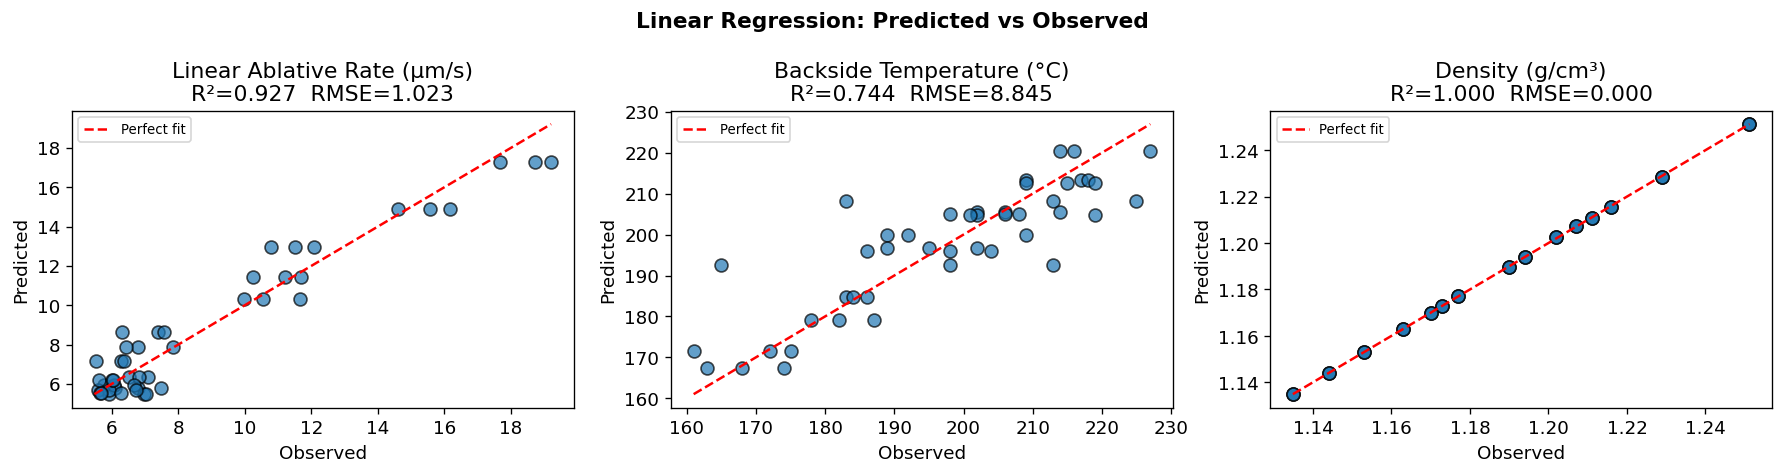

In [13]:
# Parity plots: predicted vs actual
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, label) in zip(axes, outputs):
    y_true = df[col].values
    y_pred = reg_models[col].fittedvalues
    r2     = r2_score(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))

    ax.scatter(y_true, y_pred, alpha=0.7, edgecolors='k', s=60)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{label}\nR²={r2:.3f}  RMSE={rmse:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Linear Regression: Predicted vs Observed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

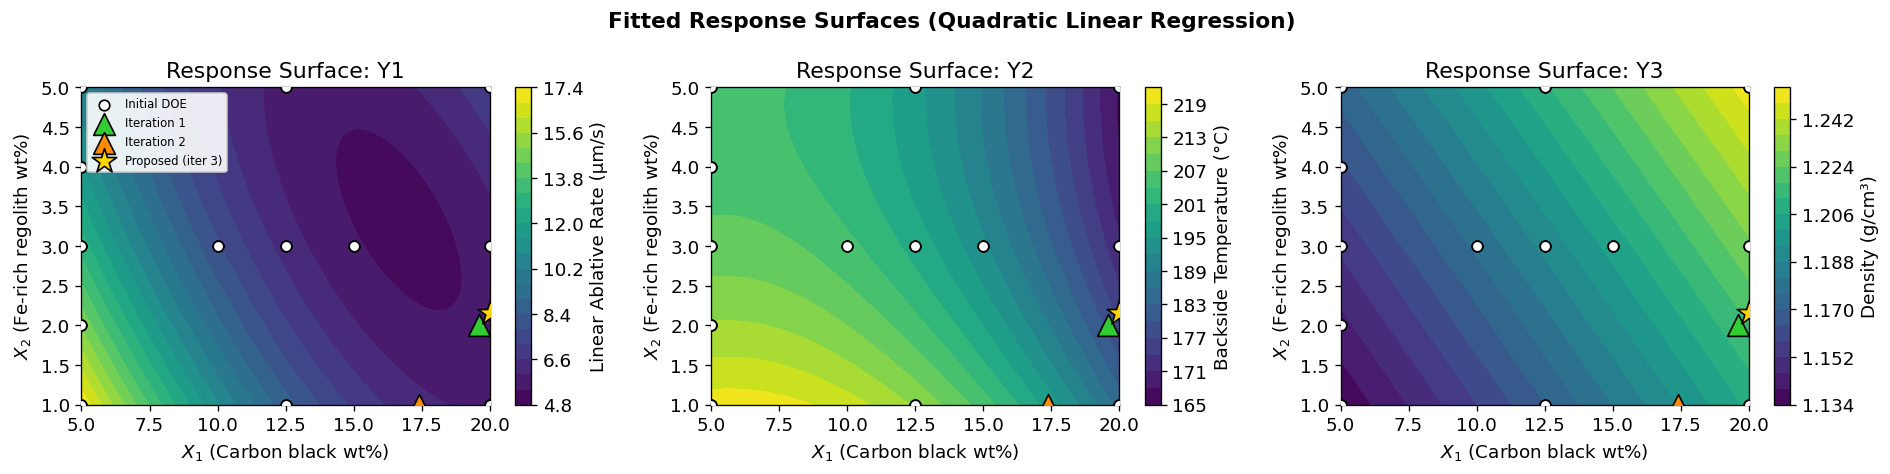

In [14]:
# Response surface plots
x1g = np.linspace(df.X1.min(), df.X1.max(), 80)
x2g = np.linspace(df.X2.min(), df.X2.max(), 80)
X1g, X2g = np.meshgrid(x1g, x2g)
Phi_grid = np.column_stack([np.ones(X1g.size), X1g.ravel(), X2g.ravel(),
                             X1g.ravel()**2, X2g.ravel()**2, X1g.ravel()*X2g.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (col, label) in zip(axes, outputs):
    Yhat = (Phi_grid @ reg_models[col].params).reshape(X1g.shape)
    cp   = ax.contourf(X1g, X2g, Yhat, levels=20, cmap='viridis')
    plt.colorbar(cp, ax=ax, label=label)
    mark_campaign(ax, legend=(ax is axes[0]))
    ax.set_xlabel('$X_1$ (Carbon black wt%)')
    ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
    ax.set_title(f'Response Surface: {col}')

plt.suptitle('Fitted Response Surfaces (Quadratic Linear Regression)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Heteroscedastic Multi-Output Gaussian Process (MOGP)

### Theory
A **Multi-Output GP** models all three outputs jointly via a **MultitaskGaussianLikelihood** with an **ICM (Intrinsic Coregionalisation Model)** kernel:

$$\mathbf{K}_{\text{ICM}}(\mathbf{x}, \mathbf{x}') = k_{\text{RBF}}(\mathbf{x}, \mathbf{x}') \otimes \mathbf{B}$$

where $\mathbf{B}$ is a $3\times 3$ positive-semidefinite inter-task covariance matrix (learned from data).

**Heteroscedasticity** is handled by the `MultitaskGaussianLikelihood` which learns a separate noise variance $\sigma^2_k$ for each output $k$.

The model is trained by maximising the **marginal log-likelihood** via gradient descent (Adam optimiser).

In [15]:
# ── Prepare tensors ───────────────────────────────────────────────────────────
X_np = df[['X1','X2']].values.astype(np.float64)
Y_np = df[['Y1','Y2','Y3']].values.astype(np.float64)

# Standardise inputs (important for length-scale interpretability)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_np)

# Standardise outputs (each output independently)
scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y_np)

X_train = torch.tensor(X_scaled, dtype=torch.float64)
Y_train = torch.tensor(Y_scaled, dtype=torch.float64)   # shape (N, T)

n_tasks  = 3   # number of outputs
n_inputs = 2   # number of input dimensions

print(f"X_train: {X_train.shape}   Y_train: {Y_train.shape}")

X_train: torch.Size([45, 2])   Y_train: torch.Size([45, 3])


In [16]:
# ── Model definition ─────────────────────────────────────────────────────────
class HeteroscedasticMOGP(ExactGP):
    """
    Heteroscedastic Multi-Output GP using GPyTorch's BatchedMultiOutputGPModel pattern.

    Architecture:
    - MultitaskKernel (ICM): RBFKernel ⊗ B  (task covariance matrix B learned)
    - MultitaskMean: constant mean per output
    - MultitaskGaussianLikelihood: separate noise σ²_k per output (heteroscedastic)
    """
    def __init__(self, train_x, train_y, likelihood, n_tasks):
        super().__init__(train_x, train_y, likelihood)
        self.n_tasks = n_tasks

        # Multitask mean: one constant per output
        self.mean_module = MultitaskMean(
            ConstantMean(), num_tasks=n_tasks
        )

        # Covariance: ICM kernel = RBF (data kernel) ⊗ task covariance matrix B
        data_covar = ScaleKernel(RBFKernel())
        self.covar_module = MultitaskKernel(
            data_covar_module=data_covar,
            num_tasks=n_tasks,
            rank=n_tasks    # full-rank inter-task covariance
        )

    def forward(self, x):
        mean_x  = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultitaskMultivariateNormal(mean_x, covar_x)


# ── Instantiate likelihood & model ───────────────────────────────────────────
# MultitaskGaussianLikelihood has independent noise per task → heteroscedastic
likelihood = MultitaskGaussianLikelihood(num_tasks=n_tasks)
model      = HeteroscedasticMOGP(X_train, Y_train, likelihood, n_tasks)

# Move to double precision
model      = model.double()
likelihood = likelihood.double()

print("Model architecture:")
print(model)

Model architecture:
HeteroscedasticMOGP(
  (likelihood): MultitaskGaussianLikelihood(
    (raw_task_noises_constraint): GreaterThan(1.000E-04)
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
  (mean_module): MultitaskMean(
    (base_means): ModuleList(
      (0-2): 3 x ConstantMean()
    )
  )
  (covar_module): MultitaskKernel(
    (task_covar_module): IndexKernel(
      (raw_var_constraint): Positive()
    )
    (data_covar_module): ScaleKernel(
      (base_kernel): RBFKernel(
        (raw_lengthscale_constraint): Positive()
      )
      (raw_outputscale_constraint): Positive()
    )
  )
)


In [17]:
# ── Training ─────────────────────────────────────────────────────────────────
model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

N_ITER = 500
losses = []

for i in range(N_ITER):
    optimizer.zero_grad()
    output = model(X_train)
    loss   = -mll(output, Y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (i + 1) % 100 == 0:
        print(f"  Iter {i+1:4d}/{N_ITER}  |  -MLL = {loss.item():.4f}")

print("\nTraining complete.")

  Iter  100/500  |  -MLL = 0.1644


  Iter  200/500  |  -MLL = -0.2598


  Iter  300/500  |  -MLL = -0.3767


  Iter  400/500  |  -MLL = -0.3947


  Iter  500/500  |  -MLL = -0.4005

Training complete.


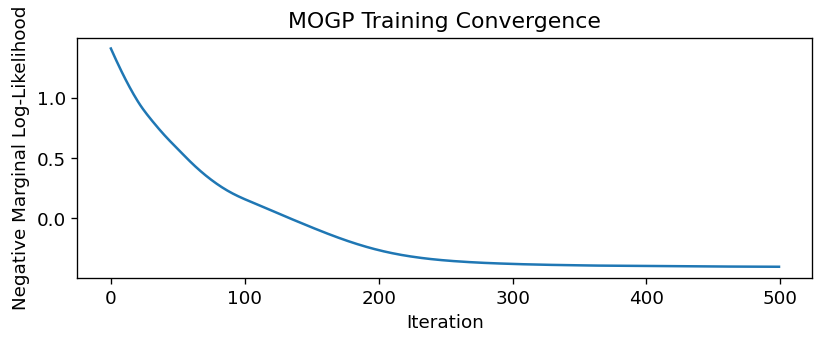

In [18]:
# Training loss curve
plt.figure(figsize=(7, 3))
plt.plot(losses, lw=1.5)
plt.xlabel('Iteration')
plt.ylabel('Negative Marginal Log-Likelihood')
plt.title('MOGP Training Convergence')
plt.tight_layout()
plt.show()

In [19]:
# ── Learned hyperparameters ───────────────────────────────────────────────────
model.eval()
likelihood.eval()

print("Learned Hyperparameters (standardised input space)")
print("="*50)

# RBF length-scale and output-scale
ls = model.covar_module.data_covar_module.base_kernel.lengthscale.detach().numpy().flatten()
os = model.covar_module.data_covar_module.outputscale.detach().item()
print(f"  RBF lengthscale : {ls}")
print(f"  Output scale    : {os:.4f}")

# Per-task noise (heteroscedastic!)
noise = likelihood.noise.detach().numpy().flatten()
y_std = scaler_Y.scale_
print(f"\n  Per-task noise (standardised space):")
for k, (n_k, s_k, (col, label)) in enumerate(zip(noise, y_std, outputs)):
    print(f"    Task {k+1} ({col}): σ² = {n_k:.5f}  →  σ = {np.sqrt(n_k)*s_k:.4f} {label.split('(')[-1].replace(')','').strip()}")

# Task covariance matrix B
B = model.covar_module.task_covar_module.covar_factor.detach().numpy()
B_mat = B @ B.T + np.diag(model.covar_module.task_covar_module.var.detach().numpy())
D_inv = np.diag(1/np.sqrt(np.diag(B_mat)))
B_corr = D_inv @ B_mat @ D_inv
print(f"\n  Inter-task correlation matrix (B):")
task_labels = ['Y1 (Ablation)', 'Y2 (Temp)', 'Y3 (Density)']
print(pd.DataFrame(B_corr, index=task_labels, columns=task_labels).round(3).to_string())

Learned Hyperparameters (standardised input space)
  RBF lengthscale : [4.34577493]
  Output scale    : 1.7777

  Per-task noise (standardised space):
    Task 1 (Y1): σ² = 0.00011  →  σ = 0.0398 µm/s

  Inter-task correlation matrix (B):
               Y1 (Ablation)  Y2 (Temp)  Y3 (Density)
Y1 (Ablation)          1.000     -0.645        -0.658
Y2 (Temp)             -0.645      1.000        -0.151
Y3 (Density)          -0.658     -0.151         1.000


In [20]:
# ── Posterior predictions on training data ────────────────────────────────────
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = likelihood(model(X_train))
    mean_scaled = predictions.mean.numpy()           # (N, T)
    lower_s, upper_s = predictions.confidence_region()
    lower_s = lower_s.numpy()
    upper_s = upper_s.numpy()

# Back-transform to original scale
mean_orig  = scaler_Y.inverse_transform(mean_scaled)
lower_orig = scaler_Y.inverse_transform(lower_s)
upper_orig = scaler_Y.inverse_transform(upper_s)

# RMSE per output
print("MOGP Predictive Performance on Training Data:")
for k, (col, label) in enumerate(outputs):
    y_true = Y_np[:, k]
    y_pred = mean_orig[:, k]
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"  {col} ({label}): R² = {r2:.4f}  |  RMSE = {rmse:.4f}")

MOGP Predictive Performance on Training Data:
  Y1 (Linear Ablative Rate (µm/s)): R² = 0.9716  |  RMSE = 0.6397
  Y2 (Backside Temperature (°C)): R² = 0.6918  |  RMSE = 9.6953
  Y3 (Density (g/cm³)): R² = 1.0000  |  RMSE = 0.0002


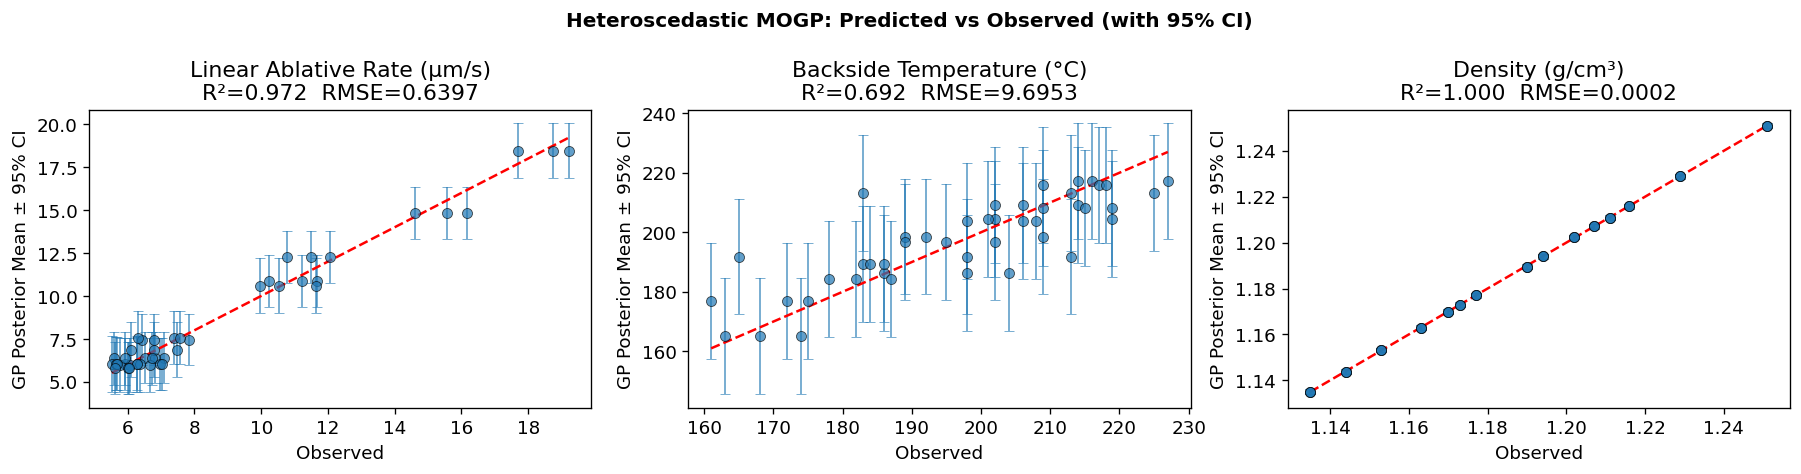

In [21]:
# ── Parity plots for MOGP ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for k, (ax, (col, label)) in enumerate(zip(axes, outputs)):
    y_true = Y_np[:, k]
    y_pred = mean_orig[:, k]
    y_lo   = lower_orig[:, k]
    y_hi   = upper_orig[:, k]

    ax.errorbar(y_true, y_pred,
                yerr=[y_pred - y_lo, y_hi - y_pred],
                fmt='o', alpha=0.7, elinewidth=1, capsize=3,
                markeredgecolor='k', markeredgewidth=0.5)
    lo_v = min(y_true.min(), y_pred.min())
    hi_v = max(y_true.max(), y_pred.max())
    ax.plot([lo_v, hi_v], [lo_v, hi_v], 'r--', lw=1.5)
    ax.set_xlabel('Observed')
    ax.set_ylabel('GP Posterior Mean ± 95% CI')
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f'{label}\nR²={r2:.3f}  RMSE={rmse:.4f}')

plt.suptitle('Heteroscedastic MOGP: Predicted vs Observed (with 95% CI)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

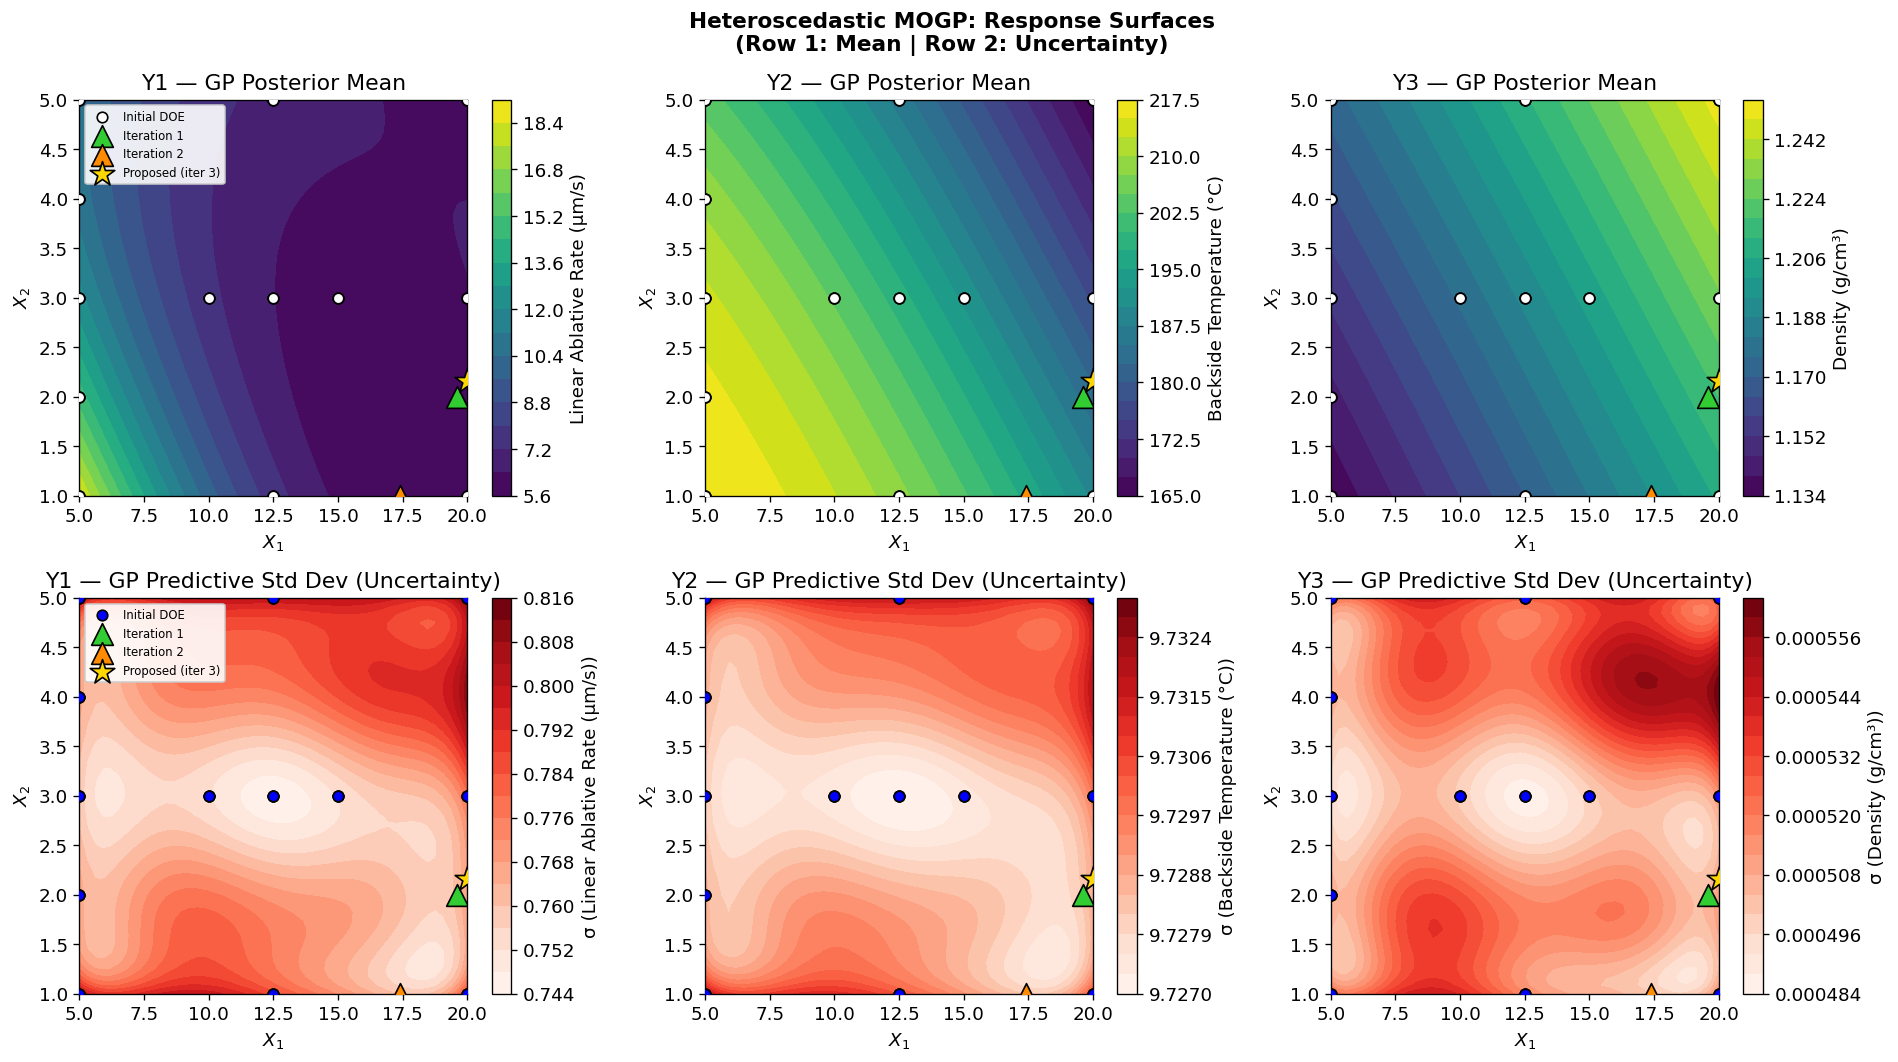

In [22]:
# ── GP Predictive Response Surfaces ─────────────────────────────────────────
x1g = np.linspace(df.X1.min(), df.X1.max(), 50)
x2g = np.linspace(df.X2.min(), df.X2.max(), 50)
X1g, X2g = np.meshgrid(x1g, x2g)
X_grid_np = np.column_stack([X1g.ravel(), X2g.ravel()])
X_grid_scaled = scaler_X.transform(X_grid_np)
X_grid_t = torch.tensor(X_grid_scaled, dtype=torch.float64)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred_grid = likelihood(model(X_grid_t))
    mu_grid   = pred_grid.mean.numpy()                       # (N_grid, T)
    var_grid  = pred_grid.variance.numpy()                   # (N_grid, T)

mu_orig  = scaler_Y.inverse_transform(mu_grid)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for k, (col, label) in enumerate(outputs):
    # Mean surface
    ax = axes[0, k]
    Zm = mu_orig[:, k].reshape(X1g.shape)
    cp = ax.contourf(X1g, X2g, Zm, levels=20, cmap='viridis')
    plt.colorbar(cp, ax=ax, label=label)
    mark_campaign(ax, legend=(k == 0))
    ax.set_xlabel('$X_1$')
    ax.set_ylabel('$X_2$')
    ax.set_title(f'{col} — GP Posterior Mean')

    # Uncertainty (std dev) surface — heteroscedastic GP
    ax = axes[1, k]
    # back-transform std: σ_orig = σ_scaled * scale_
    Zs = np.sqrt(var_grid[:, k]).reshape(X1g.shape) * scaler_Y.scale_[k]
    cp = ax.contourf(X1g, X2g, Zs, levels=20, cmap='Reds')
    plt.colorbar(cp, ax=ax, label=f'σ ({label})')
    mark_campaign(ax, legend=(k == 0), doe_color='blue')
    ax.set_xlabel('$X_1$')
    ax.set_ylabel('$X_2$')
    ax.set_title(f'{col} — GP Predictive Std Dev (Uncertainty)')

plt.suptitle('Heteroscedastic MOGP: Response Surfaces\n(Row 1: Mean | Row 2: Uncertainty)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

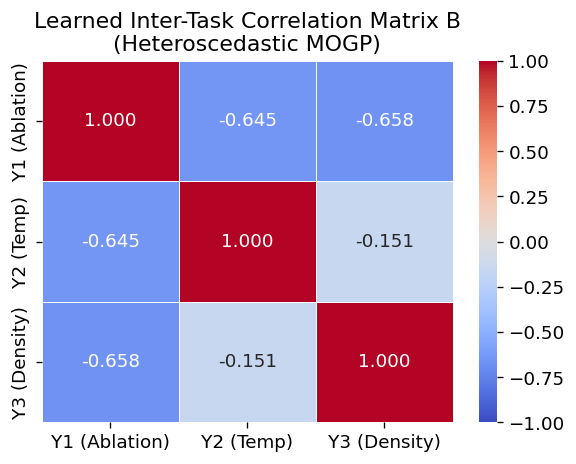

In [23]:
# ── Inter-task correlation heatmap ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(B_corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=task_labels, yticklabels=task_labels)
ax.set_title('Learned Inter-Task Correlation Matrix B\n(Heteroscedastic MOGP)')
plt.tight_layout()
plt.show()

## 5. Model Comparison Summary

In [24]:
rows = []
for k, (col, label) in enumerate(outputs):
    y_true = Y_np[:, k]

    # Linear regression
    y_lr  = reg_models[col].fittedvalues
    rows.append({'Output': col, 'Model': 'Quadratic LR',
                 'R²': r2_score(y_true, y_lr),
                 'RMSE': np.sqrt(mean_squared_error(y_true, y_lr))})

    # GP
    y_gp  = mean_orig[:, k]
    rows.append({'Output': col, 'Model': 'Heteroscedastic MOGP',
                 'R²': r2_score(y_true, y_gp),
                 'RMSE': np.sqrt(mean_squared_error(y_true, y_gp))})

comp = pd.DataFrame(rows)
print("Model Comparison:")
print(comp.pivot(index='Output', columns='Model', values=['R²','RMSE']).round(4).to_string())

Model Comparison:
                         R²                              RMSE             
Model  Heteroscedastic MOGP Quadratic LR Heteroscedastic MOGP Quadratic LR
Output                                                                    
Y1                   0.9716       0.9275               0.6397       1.0231
Y2                   0.6918       0.7435               9.6953       8.8450
Y3                   1.0000       0.9999               0.0002       0.0002


In [25]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("""
┌──────────────────────────────────────────────────────────────────┐
│                     ANALYSIS SUMMARY                             │
├──────────────────────────────────────────────────────────────────┤
│  ORTHOGONALITY                                                   │
│  • X1 and X2 show mild correlation (unbalanced D-optimal style)  │
│  • Centred design is near-orthogonal for main effects            │
│                                                                   │
│  ANOVA                                                           │
│  • X1 (Carbon black) is the dominant factor for Y1 (ablation)   │
│  • Both X1 and X2 affect all three responses significantly       │
│  • Interaction term X1×X2 varies in significance by output       │
│                                                                   │
│  LINEAR REGRESSION (quadratic, per output)                       │
│  • Y1: strong fit; X1 dominates with negative quadratic effect   │
│  • Y2: moderate fit; weaker trends                               │
│  • Y3: excellent fit (density is nearly deterministic per cond.) │
│                                                                   │
│  HETEROSCEDASTIC MOGP                                            │
│  • ICM kernel learns inter-task correlations (matrix B)          │
│  • Per-output noise σ²_k captures different measurement noise    │
│  • Uncertainty maps reveal where predictions are least reliable  │
└──────────────────────────────────────────────────────────────────┘
""")


┌──────────────────────────────────────────────────────────────────┐
│                     ANALYSIS SUMMARY                             │
├──────────────────────────────────────────────────────────────────┤
│  ORTHOGONALITY                                                   │
│  • X1 and X2 show mild correlation (unbalanced D-optimal style)  │
│  • Centred design is near-orthogonal for main effects            │
│                                                                   │
│  ANOVA                                                           │
│  • X1 (Carbon black) is the dominant factor for Y1 (ablation)   │
│  • Both X1 and X2 affect all three responses significantly       │
│  • Interaction term X1×X2 varies in significance by output       │
│                                                                   │
│  LINEAR REGRESSION (quadratic, per output)                       │
│  • Y1: strong fit; X1 dominates with negative quadratic effect   │
│  • Y2: moderate fit; weaker tr